In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer

### Data Cleaning

I Decided to drop the Unnamed: 0 column as it was just another index column

In [73]:
data = pd.read_csv('yield_df.csv')
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [74]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 2.1 MB


In [75]:
data.drop(columns = 'Unnamed: 0', inplace = True)

### EDA

First I understood the types of values in each column and chcked for missing values, there were no missing values.Then I decided to check the value counts of my columns to get a general what values are in each column. Then checking for the distribution of numeric columns I found they were either skewed to the left or right.

In [76]:
data.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [77]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.9 MB


In [78]:
data['Item'].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

In [79]:
data['Area'].value_counts()

Area
India         4048
Brazil        2277
Mexico        1472
Pakistan      1449
Australia      966
              ... 
Latvia          42
Belgium         39
Bahrain         29
Sudan           28
Montenegro      24
Name: count, Length: 101, dtype: int64

In [80]:
data['pesticides_tonnes'].value_counts()

pesticides_tonnes
1597.00     720
34468.93    704
79821.18    462
26857.00    364
75000.00    176
           ... 
12.12         1
16.25         1
10.45         1
12.59         1
9.84          1
Name: count, Length: 1673, dtype: int64

In [81]:
data['avg_temp'].value_counts()

avg_temp
27.20    90
27.03    84
27.01    83
25.44    81
27.23    81
         ..
10.83     2
9.38      2
11.19     2
8.08      2
27.86     1
Name: count, Length: 1831, dtype: int64

In [82]:
data['Year'].value_counts()

Year
2012    1260
2013    1259
2010    1245
2011    1245
2008    1244
2006    1243
2007    1242
2009    1242
2005    1235
2004    1234
2000    1230
2001    1229
2002    1228
1997    1224
1998    1224
1993    1223
1999    1223
1995    1222
1996    1222
1994    1221
1992    1219
1990    1164
1991    1164
Name: count, dtype: int64

In [83]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

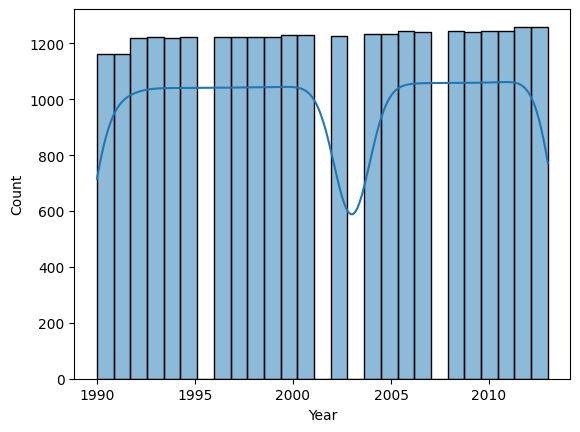

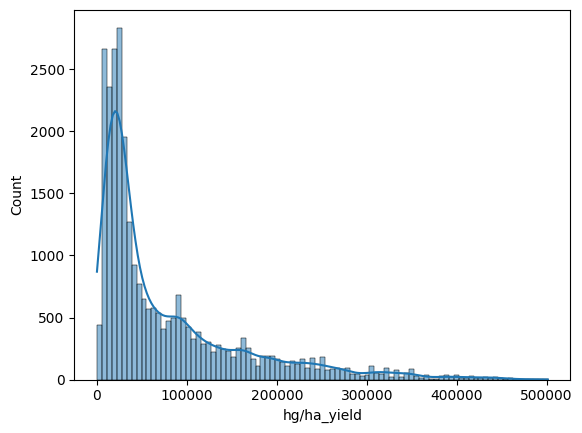

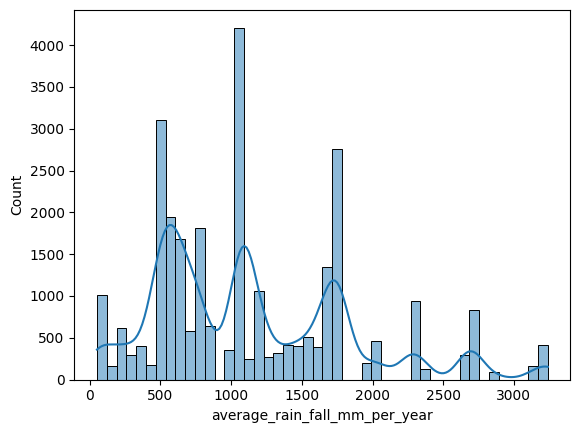

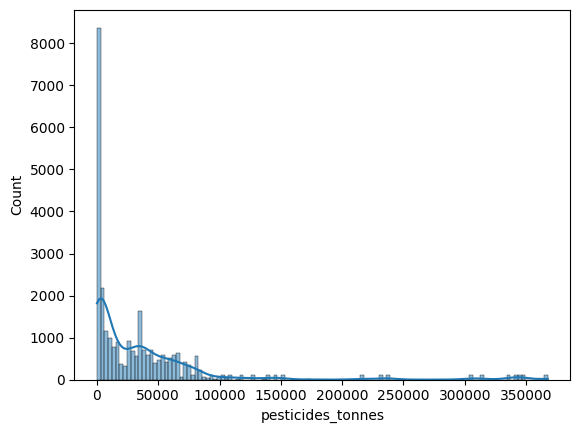

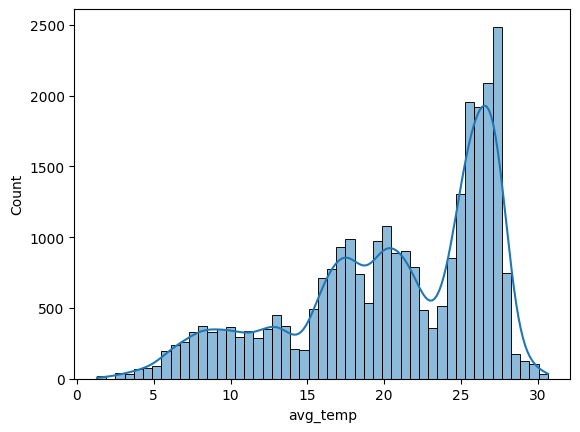

In [84]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

Using a correlation heatmap to check for multicolinearity I found there were no values that were highly positively or negatively correlated. This gives me the impression that a linear regression model would perform well. 

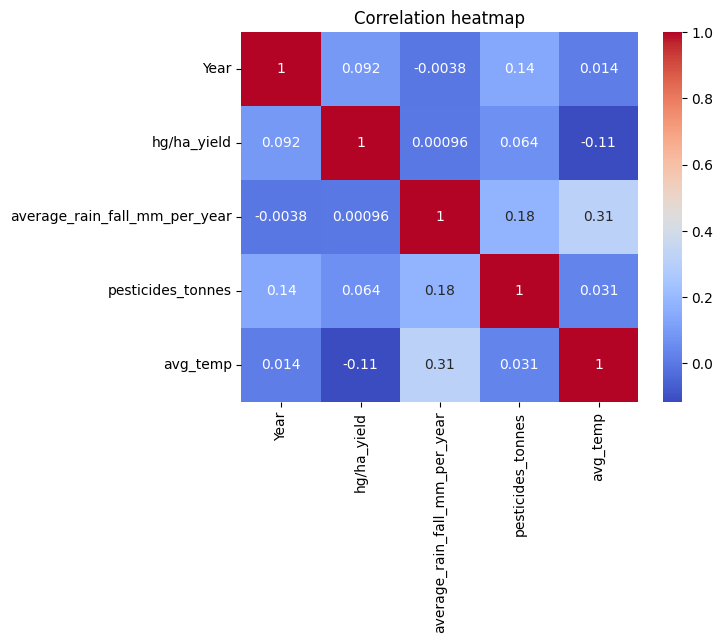

In [85]:
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation heatmap')
plt.show()

### Linear Seperability

Checked for linear seperability using the a pairplot shows a non linear relationship between features and target variable so a polynomial regression model might perform better due to this.

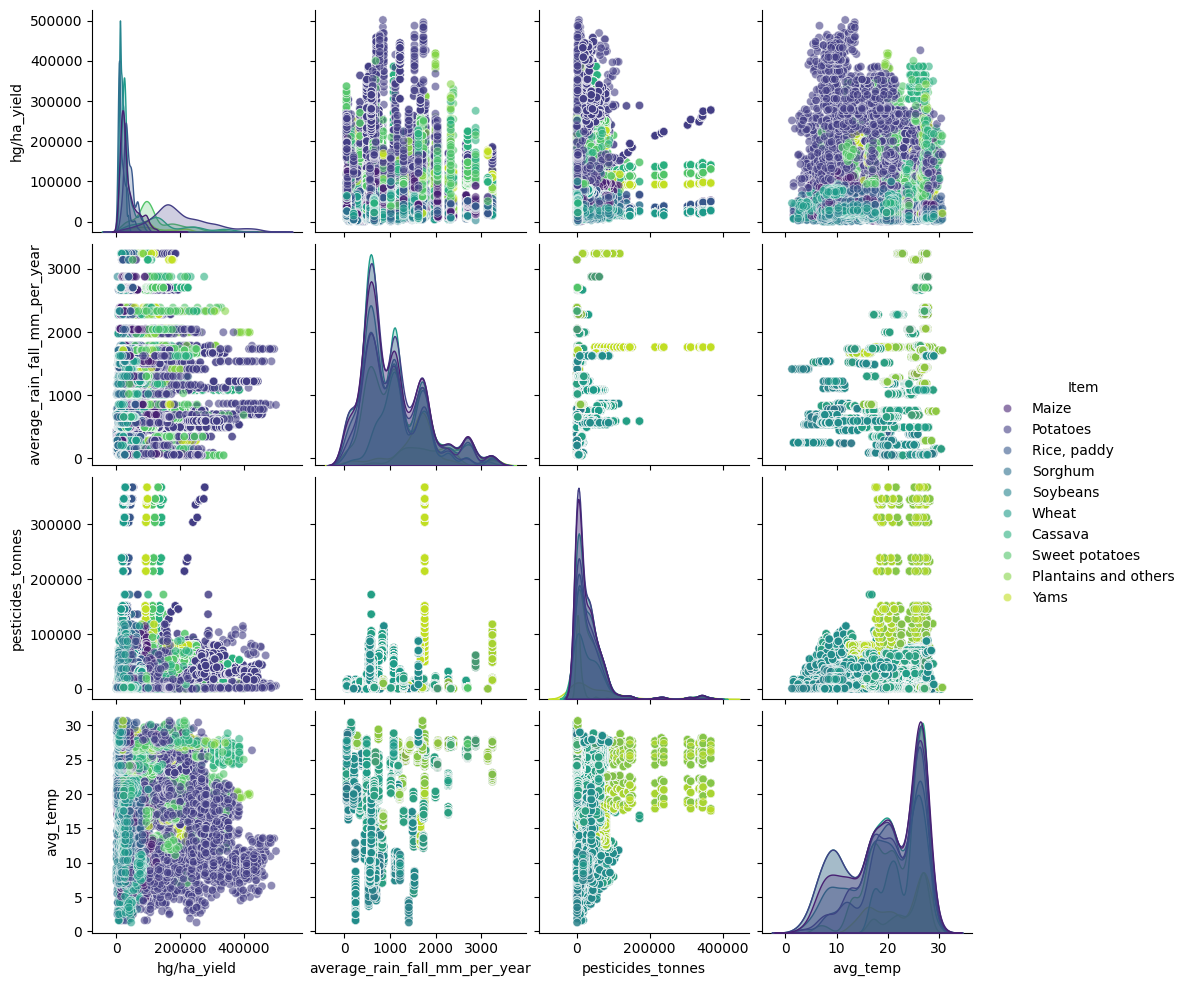

In [86]:
sns.pairplot(
    data, 
    hue='Item', 
    vars=['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

### Feature Engineering

Decided to use target enconding as both Area and item have high cardinality so the risk of overfitting using this type of encoding is reduced

In [87]:
encoder = TargetEncoder(cols=['Area', 'Item'])
data[['Area','Item']] = encoder.fit_transform(data[['Area', 'Item']], data['hg/ha_yield'])

In [88]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  float64
 1   Item                           28242 non-null  float64
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.5 MB


Model Selection

In [89]:
X = data.drop(columns = 'hg/ha_yield')
y = data['hg/ha_yield']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

Robust scaler used as all the distributions were skewed either to the left or right

In [ ]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Linear Regression

Initially decided to go with the linear regression due to the lack of multicolinearity shown earlier

In [92]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Similar R2 scores for both testing and training while the score being 0.73 shows that the model is not overfitting or underfitting

In [93]:
train_preds = lr_model.predict(X_train)
test_preds = lr_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds)}")

Training R2 score: 0.7363134388046362
Testing R2 score: 0.7423208116694449
Training MAE score: 29198.79602045978
Testing MAE score: 29042.02342505938
Training MSE score: 1900730235.4767766
Testing MSE score: 1869120305.868666
Training RMSE score: 43597.36500611908
Testing RMSE score: 43233.32402058239


Plotting actual vs Predicted values shows a decent concentraion around the prediction line for lower values but as the values increase we can see that the predictions are less than the actual values

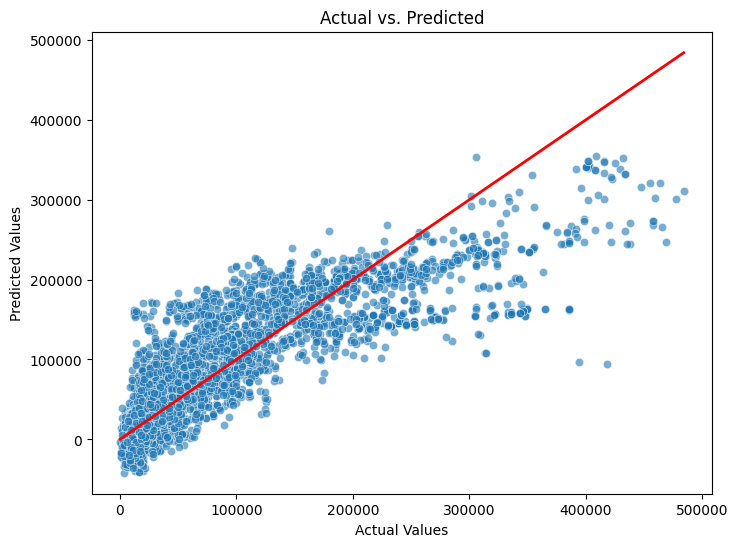

In [94]:
y_pred = lr_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

Plotting the residuals shows an almost u shaped pattern around the mean meaning the problem is not linear

Text(0.5, 1.0, 'Residual Plot')

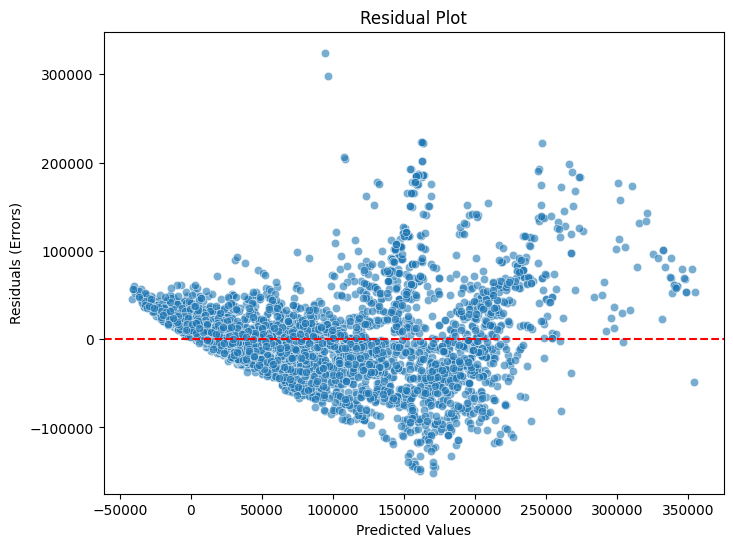

In [95]:
residuals = y_test - test_preds

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color='red', linestyle='--')
sns.scatterplot(x=test_preds, y=residuals, alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')

Knowing the problem is not linear polynomial regression is the next logical step

Polynomial Regression

In [96]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X_train)

In [97]:
poly_model = LinearRegression()
poly_model.fit(X_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_poly_pred = poly_model.predict(poly.transform(X_test))

The R2 score now improves by almost 0.1 when increasing the degree by one.

In [99]:
train_preds_poly = poly_model.predict(X_poly)
test_preds_poly = poly_model.predict(poly.transform(X_test))

print(f"Training R2 score: {r2_score(y_train, train_preds_poly)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_poly)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_poly)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_poly)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_poly)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_poly)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_poly)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_poly)}")

Training R2 score: 0.8230120130144837
Testing R2 score: 0.828935991215885
Training MAE score: 22535.669836253466
Testing MAE score: 22323.516753793454
Training MSE score: 1275781430.2500598
Testing MSE score: 1240842205.741188
Training RMSE score: 35718.08267880654
Testing RMSE score: 35225.590211395865


The residuals now seem to be scattered more randomly around 0

Text(0.5, 1.0, 'Residual Plot')

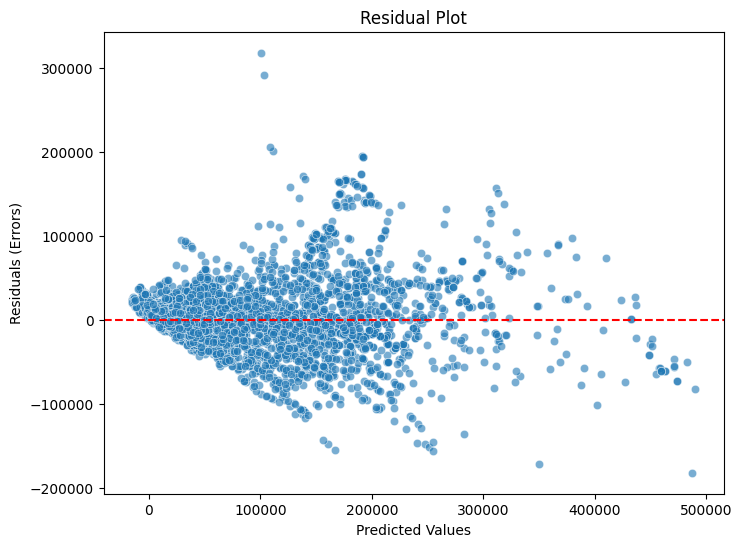

In [100]:
residuals = y_test - test_preds_poly

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color='red', linestyle='--')
sns.scatterplot(x=test_preds_poly, y=residuals, alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')

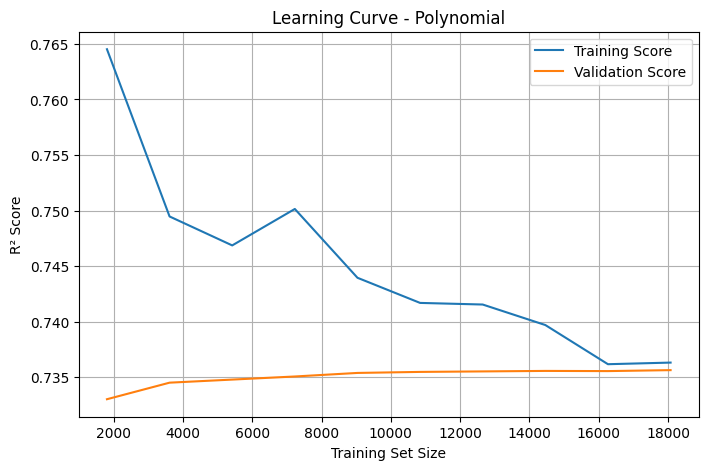

In [101]:
train_sizes, train_scores, val_scores = learning_curve(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Polynomial")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

Ridge Regularization

In [102]:
ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler_post_poly', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler_post_poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [103]:
train_preds_ridge = ridge_model.predict(X_train)
test_preds_ridge = ridge_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_ridge)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_ridge)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_ridge)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_ridge)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_ridge)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_ridge)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_ridge)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_ridge)}")

Training R2 score: 0.8230119817379928
Testing R2 score: 0.8289390560674519
Training MAE score: 22534.480493971103
Testing MAE score: 22322.038655852048
Training MSE score: 1275781655.7001987
Testing MSE score: 1240819974.3132827
Training RMSE score: 35718.08583477282
Testing RMSE score: 35225.27465206315


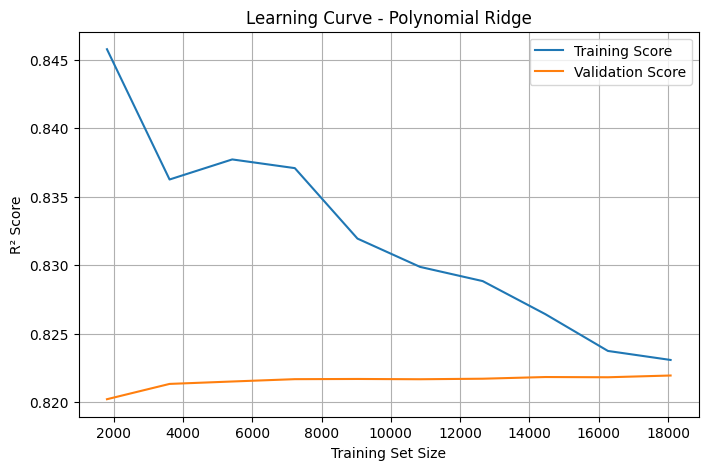

In [104]:
train_sizes, train_scores, val_scores = learning_curve(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Polynomial Ridge")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

Lasso Regularization

In [105]:
lasso_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler_post_poly', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])

lasso_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler_post_poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [106]:
train_preds_lasso = lasso_model.predict(X_train)
test_preds_lasso = lasso_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_lasso)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_lasso)}")

Training R2 score: 0.8230119887414942
Testing R2 score: 0.8289399876052118


Decision Tree

In [107]:
dt_regr_model = DecisionTreeRegressor(max_depth=5)

In [108]:
dt_regr_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [109]:
train_preds_dt = dt_regr_model.predict(X_train)
test_preds_dt = dt_regr_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_dt)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_dt)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_dt)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_dt)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_dt)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_dt)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_dt)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_dt)}")

Training R2 score: 0.848407192878285
Testing R2 score: 0.8499831257154293
Training MAE score: 19363.61757171975
Testing MAE score: 19221.710480588907
Training MSE score: 1092725509.676483
Testing MSE score: 1088173196.1548116
Training RMSE score: 33056.398921789456
Testing RMSE score: 32987.47029032101


Random Forest

In [110]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [111]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [112]:
train_preds_rf = rf_model.predict(X_train)
test_preds_rf = rf_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_rf)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_rf)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_rf)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_rf)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_rf)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_rf)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_rf)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_rf)}")

Training R2 score: 0.9983214691803083
Testing R2 score: 0.9862693787721792
Training MAE score: 1245.2249028460142
Testing MAE score: 3504.1996353336876
Training MSE score: 12099343.49973895
Testing MSE score: 99597422.34281175
Training RMSE score: 3478.4110596275063
Testing RMSE score: 9979.850817663146


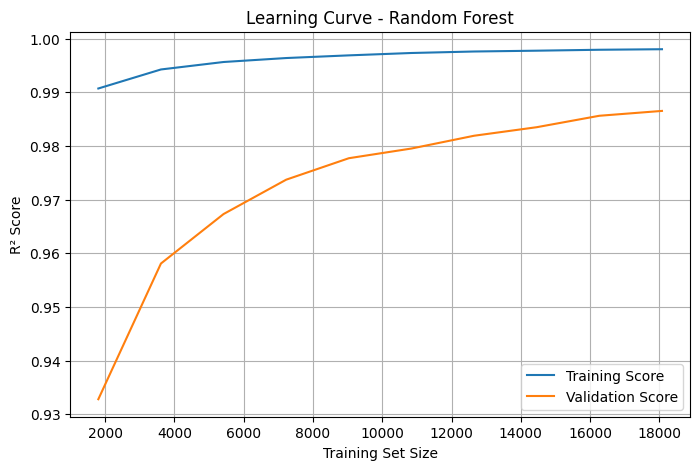

In [113]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

#### Hyperparameter Tuning

In [114]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler_post_poly', StandardScaler()),
    ('ridge', Ridge())
])
param_dist = {
    'poly__degree': randint(1, 10),
    'ridge__alpha': uniform(0.01, 10)
}

random_search = RandomizedSearchCV(
    ridge_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters (Random Search):")
print(random_search.best_params_)

print("Best CV Score:", random_search.best_score_)

Best Parameters (Random Search):
{'poly__degree': 7, 'ridge__alpha': np.float64(0.5908361216819946)}
Best CV Score: 0.9202129958134508


In [115]:
ridge_model_tuned = Pipeline([
    ('poly', PolynomialFeatures(degree=7)),
    ('scaler_post_poly', StandardScaler()),
    ('ridge', Ridge(alpha=0.591))
])

ridge_model_tuned.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler_post_poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",7
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [116]:
train_preds_ridge_2 = ridge_model_tuned.predict(X_train)
test_preds_ridge_2 = ridge_model_tuned.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_ridge_2)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_ridge_2)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_ridge_2)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_ridge_2)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_ridge_2)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_ridge_2)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_ridge_2)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_ridge_2)}")

Training R2 score: 0.9324611479204327
Testing R2 score: 0.9255181702259356
Training MAE score: 14102.817916869293
Testing MAE score: 14943.44848555651
Training MSE score: 486839896.7132659
Testing MSE score: 540266760.9708906
Training RMSE score: 22064.4487063073
Testing RMSE score: 23243.639150763174


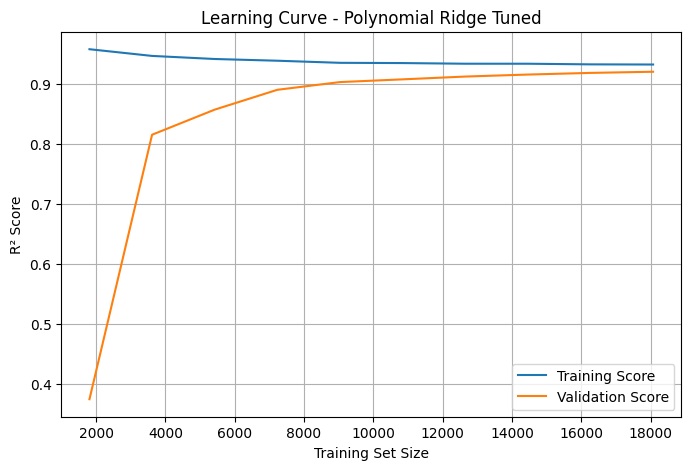

In [117]:
train_sizes, train_scores, val_scores = learning_curve(
    ridge_model_tuned,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Polynomial Ridge Tuned")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

Error Analysis

In [132]:
results = pd.DataFrame(X_test, columns = ['Area','Item','Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp'])
results['Actual'] = y_test.values
results['Predicted'] = test_preds_ridge_2

In [133]:
rmse_ridge_2 = root_mean_squared_error(y_test, test_preds_ridge_2)

errors = results[
    (results['Actual'] > results['Predicted'] + rmse_ridge_2) | 
    (results['Actual'] < results['Predicted'] - rmse_ridge_2)
]

In [134]:
errors['Difference'] = errors['Actual'] - errors['Predicted']

In [135]:
errors.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Actual,Predicted,Difference
3,-0.276345,1.838191,0.461538,2.002786,1.381572,0.637728,166986,190469.270079,-23483.270079
9,-0.224452,0.930361,-0.692308,1.911792,-0.370531,0.407288,47500,111161.815279,-63661.815279
16,-1.251617,1.283646,0.692308,-0.067781,-0.372255,0.315113,155782,70736.220730,85045.779270
21,-1.270027,1.838191,-0.846154,1.105850,-0.319107,-0.418006,71727,108454.314457,-36727.314457
22,-0.266831,1.838191,0.615385,-0.953575,-0.244420,-0.168274,194380,219614.160548,-25234.160548


In [136]:
errors[['Actual', 'Predicted','Difference']].sort_values(by='Difference').head()

,Actual,Predicted,Difference
1514,119702,271212.293789,-151510.293789
2562,100000,250139.897798,-150139.897798
870,71902,222021.788379,-150119.788379
3842,61673,193153.670949,-131480.670949
2434,29167,159364.954324,-130197.954324


In [148]:
errors[['Actual', 'Predicted', 'Difference']].sort_values(by='Difference', ascending = False).head()

,Actual,Predicted,Difference
1350,418505,175776.988952,242728.011048
3036,394286,166333.572777,227952.427223
2103,312986,115803.546062,197182.453938
3081,314369,118451.014901,195917.985099
238,288984,149273.412715,139710.587285


In [149]:
errors['Area'].value_counts()

Area
 0.236175    148
 0.493888     70
 1.273535     52
 0.000000     37
-0.155303     29
            ... 
 4.035495      1
 0.036476      1
-1.788393      1
 1.864405      1
-0.912231      1
Name: count, Length: 91, dtype: int64

In [150]:
errors['Item'].value_counts()

Item
 0.930361    296
 1.838191    246
 1.283646    204
 0.000000    106
-0.069639     67
 0.784012     58
 0.049700     45
 0.875072     41
-0.198718     19
-0.220133     18
Name: count, dtype: int64

In [138]:
results_1 = pd.DataFrame(X_test, columns = ['Area','Item','Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp'])
results_1['Actual'] = y_test.values
results_1['Predicted'] = test_preds_rf

In [139]:
rmse_rf = root_mean_squared_error(y_test, test_preds_rf)

errors_1 = results_1[
    (results_1['Actual'] > results_1['Predicted'] + rmse_rf) | 
    (results_1['Actual'] < results_1['Predicted'] - rmse_rf)
]

In [140]:
errors_1['Difference'] = errors_1['Actual'] - errors_1['Predicted']

In [141]:
errors_1[['Actual', 'Predicted','Difference']].sort_values(by='Difference').head()

,Actual,Predicted,Difference
5594,64137,207099.16,-142962.16
2838,223715,349602.33,-125887.33
4094,106800,212678.61,-105878.61
1514,119702,219619.29,-99917.29
3471,325935,416676.33,-90741.33


In [142]:
errors_1[['Actual', 'Predicted', 'Difference']].sort_values(by='Difference', ascending = False).head()

,Actual,Predicted,Difference
3081,314369,158575.26,155793.74
5071,255556,150515.69,105040.31
5212,209796,104913.21,104882.79
660,468991,365225.95,103765.05
2103,312986,209521.77,103464.23
